![image.png](https://i.imgur.com/a3uAqnb.png)

# 🧭 Introduction

In this lab, we explore **Logistic Regression and Classification** using the **QSAR Biodegradation Dataset**, which contains molecular descriptors used to predict whether a chemical compound is **Readily Biodegradable (RB)** or **Not Readily Biodegradable (NRB)**.

This experiment demonstrates the full **machine learning workflow**, including:

- Loading and preprocessing real-world chemical data  
- Implementing **Logistic Regression from scratch using NumPy**  
- Comparing with **scikit-learn models** such as Logistic Regression, Random Forest, SVM, and XGBoost  
- Evaluating models using **accuracy**, **precision**, **recall**, **F1-score**, and **confusion matrices**

The main goal is to understand how linear and nonlinear classifiers behave on chemical data and how **precision–recall tradeoffs** can guide scientific decision-making when predicting biodegradability.


### 📦 Importing Required Libraries
In this step, we import all the necessary Python libraries for data analysis, visualization, and machine learning.  
- **os, pandas, numpy** — for file handling and data manipulation.  
- **matplotlib, seaborn** — for creating plots and visualizations.  
- **sklearn** — provides tools for preprocessing, model training, evaluation, and hyperparameter tuning.  
- **xgboost** — for implementing advanced gradient boosting models.  
- **kagglehub** — used to fetch the QSAR Biodegradation dataset directly from Kaggle.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

np.random.seed(42)


### 📥 Downloading the Dataset
We use **kagglehub** to automatically download the QSAR Biodegradation dataset from Kaggle.  
This ensures the latest version of the dataset is retrieved and stored locally, with the file path printed for reference.


In [2]:
# Download latest version
path = kagglehub.dataset_download("muhammetvarl/qsarbiodegradation")
print("Path to dataset files:", path)

100%|██████████| 48.4k/48.4k [00:00<00:00, 44.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muhammetvarl/qsarbiodegradation/versions/1


### 🔍 Exploring and Understanding the Dataset
In this section, we perform **exploratory data analysis (EDA)** to understand the structure and quality of the QSAR Biodegradation dataset.

- **Load and preview data:** The dataset is loaded into a pandas DataFrame for inspection.  
- **Check for missing values:** Ensures there are no null entries that could affect model training.  
- **Class distribution:** Displays the proportion of biodegradable (RB) vs non-biodegradable (NRB) compounds to assess balance.  
- **Statistical summary:** `describe()` provides key statistics (mean, std, min, max) for all numerical features.  
- **Feature distributions:** Histograms visualize how each molecular descriptor is distributed across samples.  
- **Correlation heatmap:** A heatmap of feature correlations helps identify relationships or potential multicollinearity among molecular descriptors.


In [3]:
df = pd.read_csv(os.path.join(path,'qsar-biodeg.csv'))
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V33,V34,V35,V36,V37,V38,V39,V40,V41,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,2
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,2
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,2
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,2
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,5.431,2.8955,0,0,0,2,0,32.1,4,1,...,0,6,1,3.573,2.242,1,8.088,0,0,1
1051,5.287,3.3732,0,0,9,0,0,35.3,0,9,...,0,3,0,3.787,3.083,3,9.278,0,0,1
1052,4.869,1.7670,0,1,9,0,5,44.4,0,4,...,4,13,0,3.848,2.576,5,9.537,1,0,1
1053,5.158,1.6914,2,0,36,0,9,56.1,0,0,...,1,16,0,5.808,2.055,8,11.055,0,1,1


In [4]:
df.isnull().sum().sum()


np.int64(0)

In [5]:
df['Class'].value_counts(normalize=True)


,proportion
Class,
1,0.662559
2,0.337441


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
V1,1055.0,4.782644,0.546916,2.0000,4.48100,4.8280,5.12500,6.4960
V2,1055.0,3.069508,0.831308,0.8039,2.50275,3.0463,3.43765,9.1775
V3,1055.0,0.716588,1.462452,0.0000,0.00000,0.0000,1.00000,12.0000
V4,1055.0,0.042654,0.256010,0.0000,0.00000,0.0000,0.00000,3.0000
V5,1055.0,0.980095,2.332955,0.0000,0.00000,0.0000,1.00000,36.0000
V6,1055.0,0.290047,1.073771,0.0000,0.00000,0.0000,0.00000,13.0000
V7,1055.0,1.646445,2.224822,0.0000,0.00000,1.0000,3.00000,18.0000
V8,1055.0,37.055640,9.144466,0.0000,30.45000,37.5000,43.40000,60.7000
V9,1055.0,1.376303,1.963521,0.0000,0.00000,1.0000,2.00000,24.0000
V10,1055.0,1.803791,1.775435,0.0000,0.00000,2.0000,3.00000,12.0000


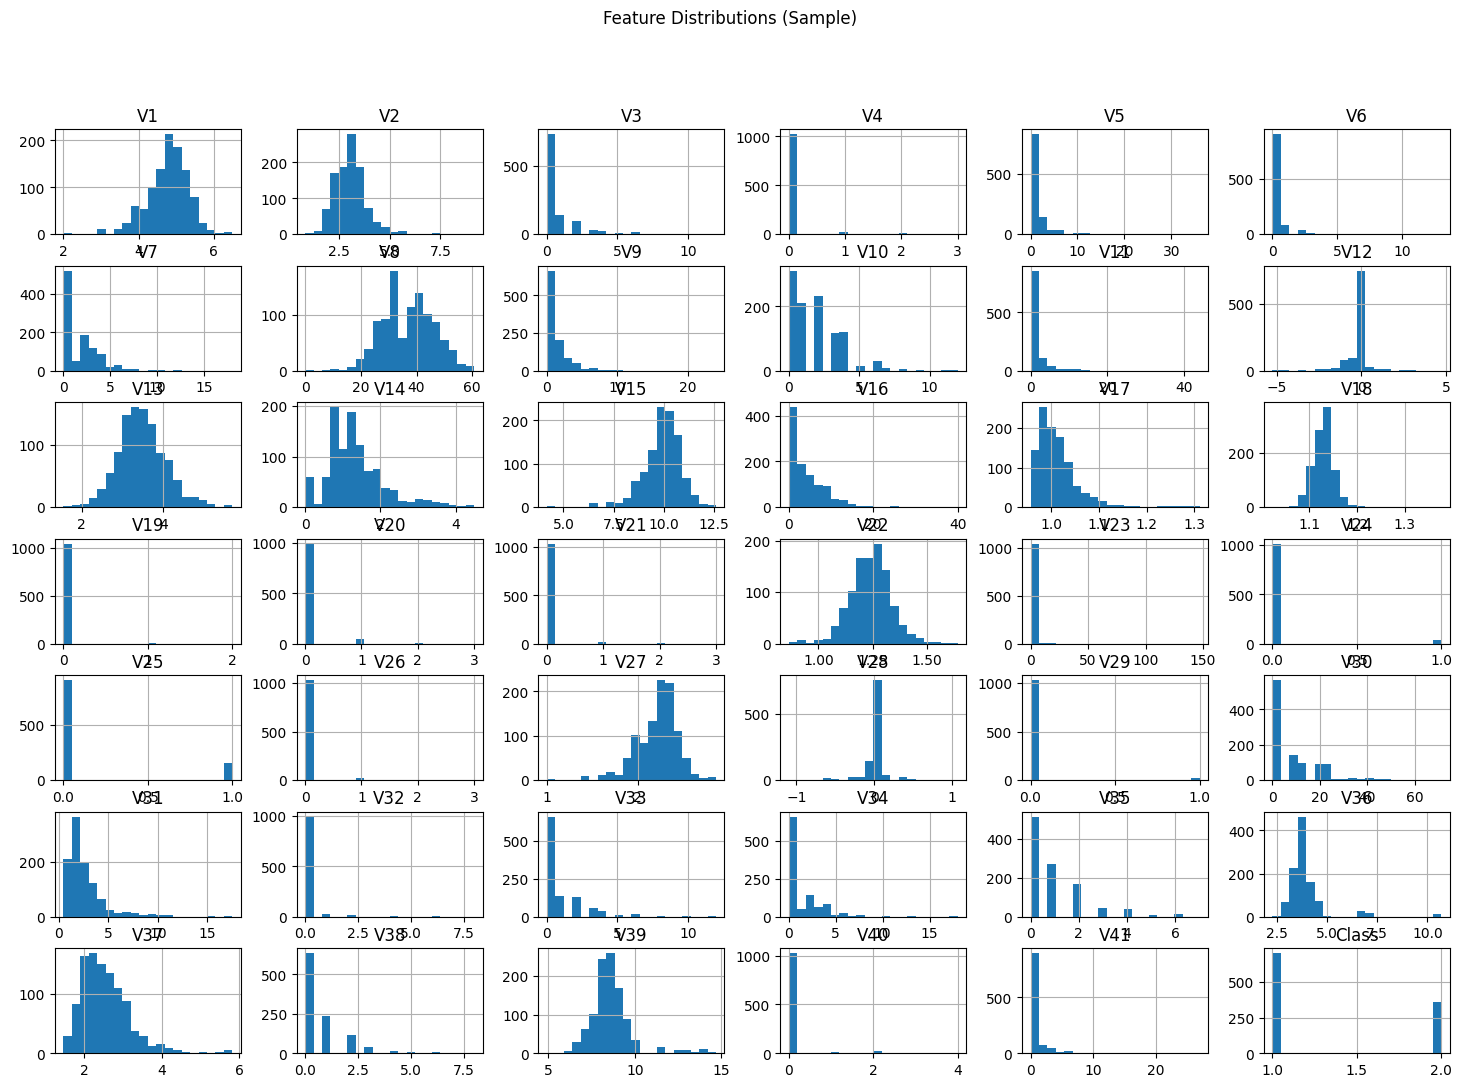

In [7]:
num_cols = df.columns[:-1]  # all except target

df[df.columns].hist(figsize=(18,12), bins=20)
plt.suptitle("Feature Distributions (Sample)")
plt.show()


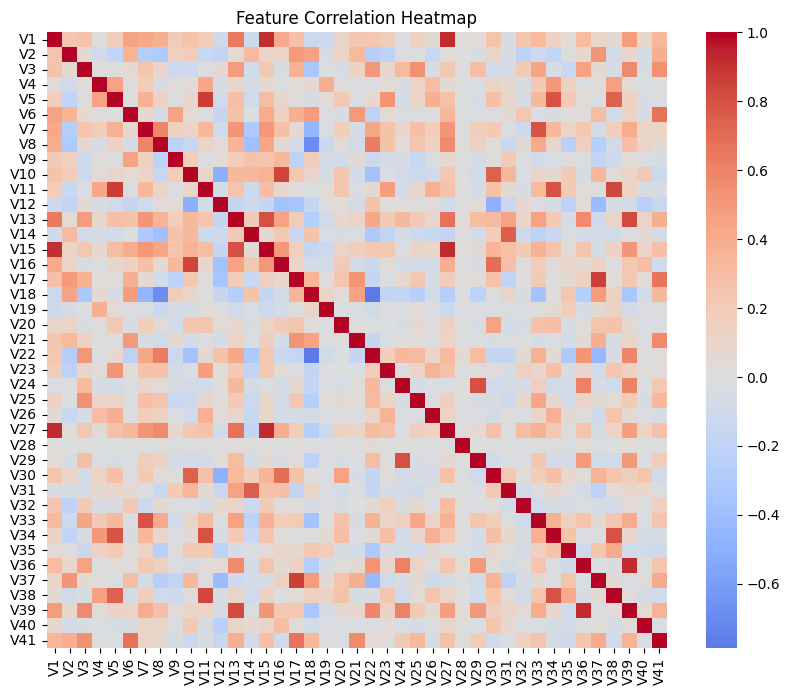

In [8]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


### Data Cleaning and Preparation Ideas
Before training our models, take a closer look at the dataset and think about how we could improve data quality.

💡 **Hints:**
- Some features have very different scales — consider **standardizing or normalizing** them.  
- A few histograms look **skewed** — maybe try applying a **log or square root transformation**.  
- Check the **correlation heatmap** — are any features too similar? Try removing redundant ones.  
- Identify and handle **outliers** that may affect model performance.

🧠 *Question:*  
Which preprocessing step do you think will have the biggest impact on model accuracy; scaling, feature selection, or class balancing? Why?




---



### 🧮 Preparing Data for Logistic Regression
Before implementing logistic regression from scratch, we need to prepare the dataset for numerical computation.

- The target variable (`Class`) is remapped from **1/2** to **0/1** for binary classification.  
  - 0 → Not Readily Biodegradable (NRB)  
  - 1 → Readily Biodegradable (RB)
- Features (`X`) and labels (`y`) are converted into **NumPy arrays** to allow efficient mathematical operations.
- The dataset is **randomly shuffled** to remove any ordering bias.
- We manually perform a **train-test split** using an 80/20 ratio to separate data for training and evaluation.
- Finally, we print the resulting shapes to verify the split.


In [9]:
# Map target: Original: 1 = NRB, 2 = RB --> After mapping: 0 = NRB, 1 = RB
df['Class'] = df['Class'].map({1: 0, 2: 1})

# Convert to NumPy arrays
X = df.drop('Class', axis=1).to_numpy()
y = df['Class'].to_numpy().reshape(-1, 1)
'''
# reshape from (n_samples,) to (n_samples,1):
[0 1 2 3 4] -> [
[0],
[1],
[2],
[3],
[4]]
'''
# Shuffle indices
indices = np.arange(len(X))
np.random.shuffle(indices)

# Define split ratio
test_ratio = 0.2
test_size = int(len(X) * test_ratio)

# Split
test_idx = indices[:test_size]
train_idx = indices[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (844, 41) (844, 1)
Test shape : (211, 41) (211, 1)


### ⚖️ Feature Standardization
We standardize all input features using **z-score normalization**:

    X' = (X - mean) / std

This process centers each feature around **mean = 0** and **std = 1**, ensuring that all features
contribute equally during training.

Key notes:
- Standardization helps gradient-based models (like logistic regression) converge faster.  
- Features with zero variance are adjusted by replacing their std with a small constant (`1e-8`) to avoid division errors.  
- The printed mean and std values confirm that scaling worked as expected.


In [10]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Avoid division by zero
std[std == 0] = 1e-8

X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test - mean) / std

# Verify scaling
print("Mean (train):", np.round(np.mean(X_train_scaled, axis=0)[:5], 3))
print("Std  (train):", np.round(np.std(X_train_scaled, axis=0)[:5], 3))

Mean (train): [ 0. -0. -0.  0. -0.]
Std  (train): [1. 1. 1. 1. 1.]


### 🧠 Sigmoid Function and Loss Definition
Here we define the key mathematical components for logistic regression:

- **Sigmoid function:**  
  Converts the linear combination of inputs (`z`) into a probability between 0 and 1.  
  This represents the predicted likelihood that a sample belongs to class **1 (RB)**.

- **Binary Cross-Entropy Loss:**  
  Measures how far the predicted probabilities (`y_hat`) are from the true labels (`y_true`).  
  Lower loss values indicate better model predictions.

Both functions are implemented with small numerical adjustments (`eps = 1e-8`) to prevent log(0) errors during computation.


In [11]:
def sigmoid(z):
    """Sigmoid activation to map any real number to [0,1] as probability of class 1 (RB)."""
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_hat):
    """Binary cross-entropy loss."""
    eps = 1e-8  # numerical stability
    return -np.mean(
        y_true * np.log(y_hat + eps) +
        (1 - y_true) * np.log(1 - y_hat + eps)
    )


### ⚙️ Model Initialization
We prepare the data and parameters needed to train logistic regression from scratch.

Steps performed:
- **Bias term:** A column of ones is added to the feature matrix to represent the intercept term.  
  This allows the model to learn a non-zero threshold for classification.
- **Shape setup:**  
  - `m` → number of training samples  
  - `n` → number of features (including bias)
- **Weight initialization:** Small random values are assigned to `W` to start gradient descent without symmetry.
- **Hyperparameters:**  
  - `lr` → learning rate controlling update step size  
  - `epochs` → number of iterations for training

In [12]:
# Add bias column (intercept term) to inputs
# X_train_scaled: (m, n_features) → X_train_bias: (m, n_features + 1)
X_train_bias = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_bias  = np.hstack([np.ones((X_test_scaled.shape[0], 1)),  X_test_scaled])

# m = number of training samples, n = number of features (including bias)
m, n = X_train_bias.shape

# Initialize weights
np.random.seed(42)
W = np.random.randn(n, 1) * 0.01  # small random weights

# Hyperparameters
lr = 0.01      # learning rate
epochs = 1000  # number of gradient descent steps

print(f"Feature matrix with bias: {X_train_bias.shape}")
print(f"W shape: {W.shape}")


Feature matrix with bias: (844, 42)
W shape: (42, 1)


### 🔁 Training the Logistic Regression Model
We now train the logistic regression model using **batch gradient descent**.

Steps performed:
1. **Forward pass:**  
   - Compute the linear combination `z = XW`.  
   - Apply the sigmoid function to get the predicted probability `y_hat`.
2. **Loss calculation:**  
   - Compute **binary cross-entropy loss** for each epoch to measure prediction error.
3. **Backward pass (Gradient computation):**  
   - Calculate the gradient of the loss with respect to weights.  
   - Update weights using the learning rate (`W -= lr * grad`).
4. **Training loop:**  
   - Repeats for the defined number of `epochs`.  
   - Prints loss every 100 epochs to track learning progress.
5. **Visualization:**  
   - The plotted curve shows how the loss decreases over time, indicating convergence.

💡 *Exercise:*  
Try changing the learning rate (`lr`) or number of epochs to observe how it affects the loss curve.


Epoch    0 | Loss = 0.6936
Epoch  100 | Loss = 0.5215
Epoch  200 | Loss = 0.4721
Epoch  300 | Loss = 0.4439
Epoch  400 | Loss = 0.4246
Epoch  500 | Loss = 0.4103
Epoch  600 | Loss = 0.3991
Epoch  700 | Loss = 0.3901
Epoch  800 | Loss = 0.3826
Epoch  900 | Loss = 0.3762


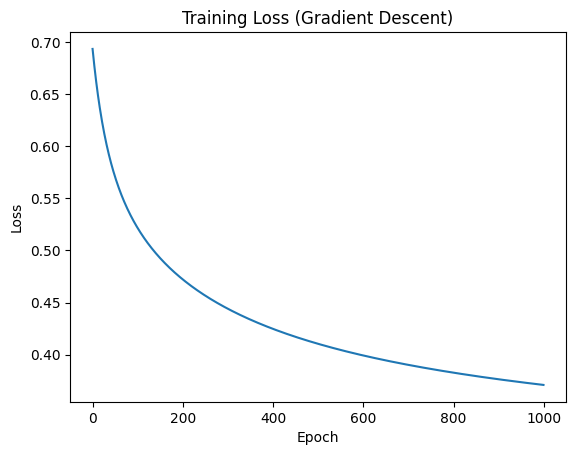

In [13]:
losses = []

for i in range(epochs):
    # Linear combination
    z = X_train_bias @ W            # shape (m,1)
    # Predicted probability of class 1 = RB
    y_hat = sigmoid(z)              # shape (m,1)

    # Compute loss (binary cross entropy)
    loss = compute_loss(y_train, y_hat)
    losses.append(loss)

    # Gradient of loss w.r.t weights - multiple steps to derive this final equation -
    grad = (X_train_bias.T @ (y_hat - y_train)) / m  # shape (n,1)

    # Gradient descent update
    W -= lr * grad

    if i % 100 == 0:
        print(f"Epoch {i:4d} | Loss = {loss:.4f}")

# visualize the loss curve
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Gradient Descent)")
plt.show()


### 🧾 Model Evaluation on Test Data
After training, we evaluate our NumPy-based logistic regression model on the **test set**.

Steps performed:
- **Prediction:**  
  - Compute probabilities using the sigmoid function.  
  - Apply a 0.5 threshold to classify samples as `RB (1)` or `NRB (0)`.

- **Performance Metrics:**  
  - **Accuracy:** Overall percentage of correct predictions.  
  - **Precision:** Of all predicted RB compounds, how many were actually RB.  
  - **Recall:** Of all true RB compounds, how many were correctly identified.  
  - **F1-score:** Harmonic mean of precision and recall, balancing both.

- **Confusion Matrix:**  
  Displays counts of true positives, false positives, true negatives, and false negatives — helping visualize classification performance.

💡 *Exercise:*  
Experiment with different thresholds (e.g., 0.4 or 0.6) and observe how precision and recall change.


Accuracy : 0.844
Precision: 0.744  (How many predicted RB were actually RB)
Recall   : 0.853  (How many true RB did we catch)
F1-score : 0.795


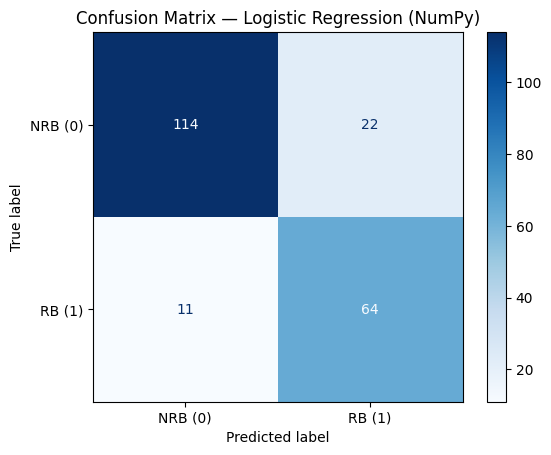

In [14]:
# Forward pass on test data
y_prob = sigmoid(X_test_bias @ W)        # probability of RB (class 1)
y_pred = (y_prob >= 0.5).astype(int)     # threshold at 0.5

# Flatten for sklearn
y_test_flat = y_test.ravel()
y_pred_flat = y_pred.ravel()

acc = accuracy_score(y_test_flat, y_pred_flat)
prec = precision_score(y_test_flat, y_pred_flat)
rec = recall_score(y_test_flat, y_pred_flat)
f1 = f1_score(y_test_flat, y_pred_flat)

# All metrics like precision_score and recall_score assume by default: “positive” = label 1

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}  (How many predicted RB were actually RB)")
print(f"Recall   : {rec:.3f}  (How many true RB did we catch)")
print(f"F1-score : {f1:.3f}")

# Confusion matrix
cm = confusion_matrix(y_test_flat, y_pred_flat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NRB (0)', 'RB (1)']
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression (NumPy)")
plt.show()


## ⚡ Logistic Regression with scikit-learn
Now that we’ve built logistic regression **from scratch**, we’ll use **scikit-learn’s built-in LogisticRegression** for comparison.

### 🔄 Data Preparation for scikit-learn Models
Here we prepare the data using scikit-learn utilities instead of doing it manually.

Steps:
1. Load the QSAR Biodegradation dataset.
2. Map the target label:
   - 0 = Not Readily Biodegradable (NRB)
   - 1 = Readily Biodegradable (RB)
3. Split the data into training and test sets using `train_test_split` with `stratify=y` to keep the same class balance in both sets.
4. Scale the features using `StandardScaler`:
   - `fit` on the training set only,
   - `transform` both train and test.
5. Wrap the scaled arrays back into DataFrames for readability.

Why this matters:
- Stratified split prevents bias in evaluation.
- Standardization helps models like Logistic Regression and SVM train more reliably.




In [15]:
# Load dataset
df = pd.read_csv(os.path.join(path, 'qsar-biodeg.csv'))

# Map: 1 → NRB (0), 2 → RB (1)
df['Class'] = df['Class'].map({1: 0, 2: 1})

# Split features and labels
X = df.drop('Class', axis=1)
y = df['Class']

# Split into train/test sets (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numerical features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames (optional for exploration)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Train shape: (844, 41) Test shape: (211, 41)


### 🧩 Evaluation Helper Function
We define a reusable helper function to **evaluate and visualize** model performance.

What it does:
- Computes key classification metrics:
  - **Accuracy** — overall correctness of predictions.  
  - **Precision** — proportion of predicted RB compounds that were truly RB.  
  - **Recall** — proportion of true RB compounds correctly identified.  
  - **F1-score** — harmonic mean of precision and recall.
- Prints a **classification report** for detailed per-class results.
- Displays a **confusion matrix** for quick visual interpretation of correct vs. incorrect predictions.
- Returns a dictionary of metrics for later comparison between models.



In [16]:
# Evaluation helper function

def evaluate_model(name, y_true, y_pred, ax=None, labels=('NRB','RB')):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['NRB','RB']))
    print("-"*40)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', ax=ax)
    if ax is not None:
        ax.set_title(f"{name} Confusion Matrix")

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


### 🤖 Training Multiple Classification Models
In this step, we train several different classifiers on the biodegradation dataset to compare their behavior.

Models trained:

1. Logistic Regression  
   - A linear baseline model.  
   - Trained on scaled features.

2. Random Forest  
   - An ensemble of decision trees that can capture nonlinear patterns.  
   - Works well on the raw (unscaled) features.  
   - Also uses class weighting for imbalance.

3. SVM (RBF Kernel)  
   - Learns a nonlinear decision boundary using the radial basis function kernel.  
   - `probability=True` lets us later compute curves like Precision–Recall.  
   - Trained on scaled features because SVM is sensitive to feature magnitude.

4. XGBoost  
   - Gradient-boosted decision trees, very strong on tabular data.  
   - `scale_pos_weight` is set based on class ratio to make the model pay more attention to the minority class.  
   - Other parameters (depth, learning rate, subsample, etc.) control regularization and generalization.

After fitting each model on the training set, we generate predictions on the test set for later evaluation.


In [17]:
# Train all models
# 1. Logistic Regression (linear baseline)
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # handle slight imbalance
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# 2. Random Forest (tree ensemble on raw features)
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. SVM with RBF kernel (margin-based nonlinear model)
svm_clf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,  # we want predict_proba for PR curve later
    random_state=42
)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

# 4. XGBoost (boosted trees on raw features)
# scale_pos_weight balances classes: (#negative / #positive)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.07,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("Trained all models.")


Trained all models.


=== Logistic Regression ===
Accuracy : 0.844
Precision: 0.716
Recall   : 0.887
F1-score : 0.792

Classification Report:
              precision    recall  f1-score   support

         NRB       0.93      0.82      0.87       140
          RB       0.72      0.89      0.79        71

    accuracy                           0.84       211
   macro avg       0.83      0.85      0.83       211
weighted avg       0.86      0.84      0.85       211

----------------------------------------
=== Random Forest ===
Accuracy : 0.867
Precision: 0.864
Recall   : 0.718
F1-score : 0.785

Classification Report:
              precision    recall  f1-score   support

         NRB       0.87      0.94      0.90       140
          RB       0.86      0.72      0.78        71

    accuracy                           0.87       211
   macro avg       0.87      0.83      0.84       211
weighted avg       0.87      0.87      0.86       211

----------------------------------------
=== SVM (RBF) ===
Accuracy : 0

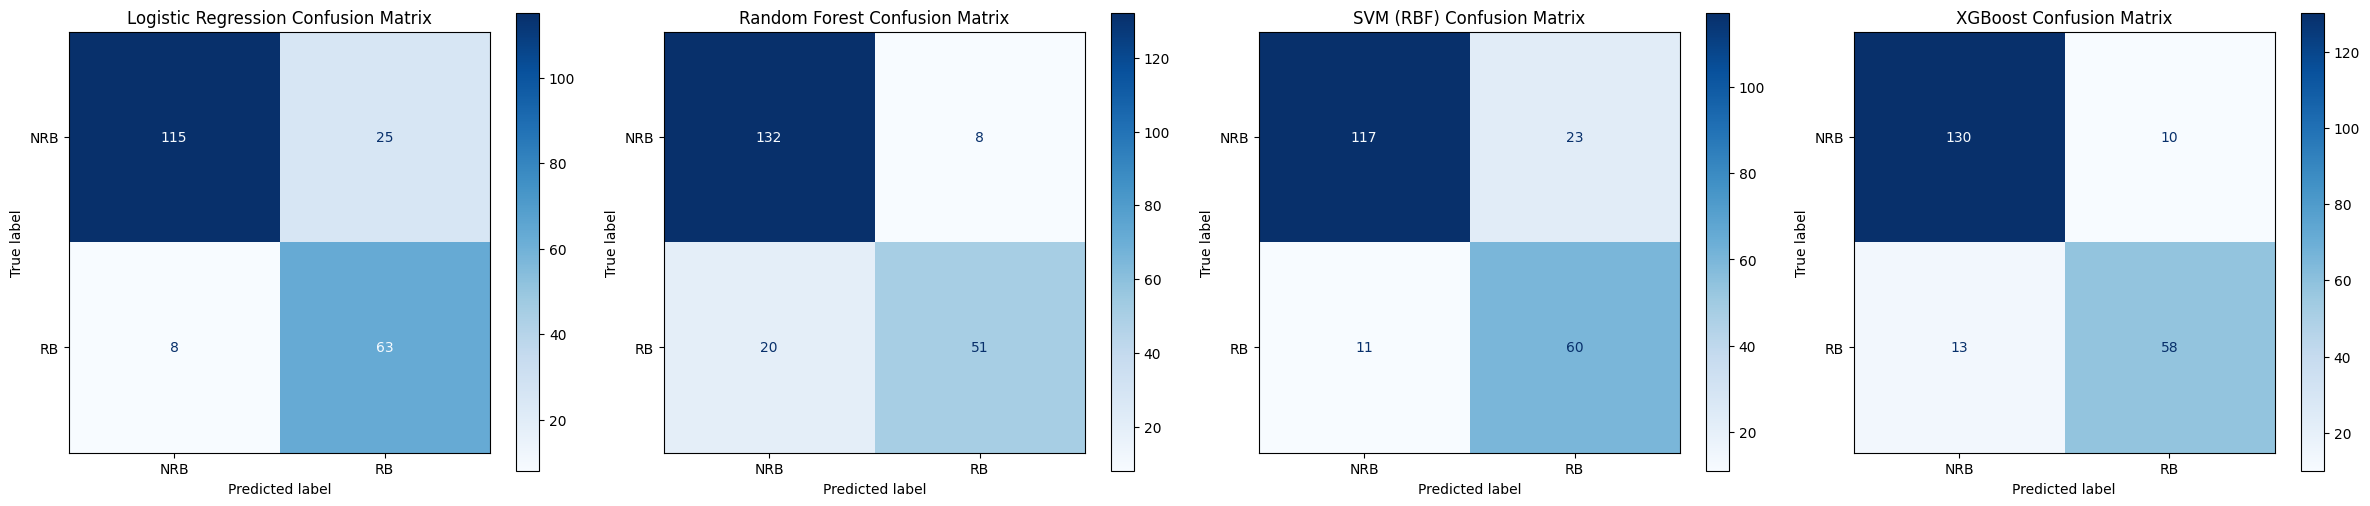

                 model  accuracy  precision    recall        f1
0  Logistic Regression  0.843602   0.715909  0.887324  0.792453
1        Random Forest  0.867299   0.864407  0.718310  0.784615
2            SVM (RBF)  0.838863   0.722892  0.845070  0.779221
3              XGBoost  0.890995   0.852941  0.816901  0.834532


In [18]:
# Evaluate and visualize all models

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, ax=axes[0]))
results.append(evaluate_model("Random Forest",        y_test, y_pred_rf, ax=axes[1]))
results.append(evaluate_model("SVM (RBF)",            y_test, y_pred_svm, ax=axes[2]))
results.append(evaluate_model("XGBoost",              y_test, y_pred_xgb, ax=axes[3]))

plt.tight_layout()
plt.show()

# Collect metrics in a summary table
results_df = pd.DataFrame(results)
print(results_df)


### 📈 Precision–Recall Tradeoff Visualization
Here we analyze how changing the **decision threshold** affects model performance for the Logistic Regression classifier.

Steps:
- Obtain predicted probabilities (`predict_proba`) for the **RB (class 1)** label.
- Compute **precision** and **recall** at various thresholds using `precision_recall_curve`.
- Plot both metrics as the threshold changes.

Interpretation:
- **Lower thresholds** → higher recall, lower precision (model predicts RB more easily).  
- **Higher thresholds** → higher precision, lower recall (model becomes stricter).  
- This helps visualize the tradeoff between **catching more RB compounds** and **avoiding false positives**.



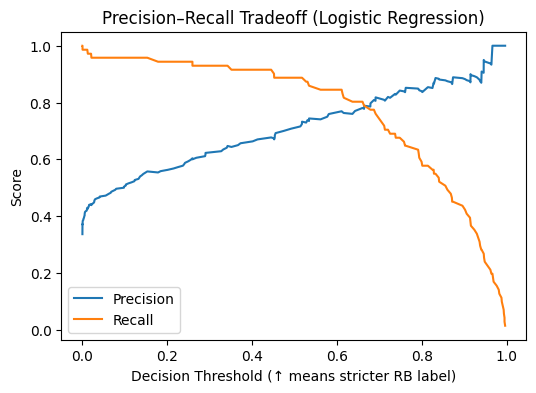

In [19]:
# We'll use Logistic Regression here since it's interpretable
y_scores_lr = log_reg.predict_proba(X_test_scaled)[:,1]  # probability of RB (class 1)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_lr)

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1],    label='Recall')
plt.xlabel("Decision Threshold (↑ means stricter RB label)")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff (Logistic Regression)")
plt.legend()
plt.show()


### 🧬 Feature Importance Analysis (XGBoost)
We use **XGBoost’s feature importance scores** to identify which molecular descriptors have the strongest influence on biodegradability prediction.

Steps:
- Extract importance values from the trained `xgb_clf`.
- Sort and visualize the **top 15 most important features** using a horizontal bar chart.

Interpretation:
- Features with higher importance contribute more to model decisions.
- Understanding these helps in **scientific interpretation**, revealing which chemical descriptors most affect a compound’s biodegradability.




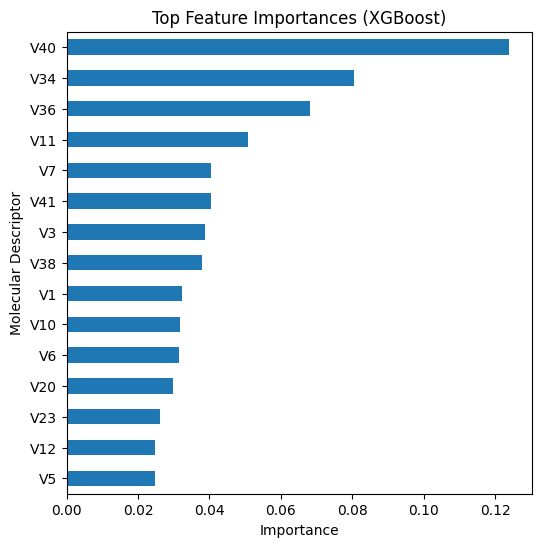

In [20]:
# XGBoost feature importance
importances = xgb_clf.feature_importances_
imp_series = pd.Series(importances, index=X.columns).sort_values(ascending=False)

top_k = 15
plt.figure(figsize=(6,6))
imp_series.head(top_k).iloc[::-1].plot(kind='barh')
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Molecular Descriptor")
plt.show()


### 🎯 Hyperparameter Tuning with Grid Search (XGBoost)
Here we tune the XGBoost model to improve performance, especially on the minority class.

What we do:
1. Compute `scale_pos_weight`  
   - This is the ratio of negative to positive samples (NRB / RB).  
   - It tells XGBoost to pay more attention to the minority class.

2. Define a search space (`param_grid`) for important hyperparameters:  
   - `n_estimators`: number of boosting rounds  
   - `max_depth`: how deep each tree can grow  
   - `learning_rate`: how fast the model learns  
   - `subsample`, `colsample_bytree`: randomness/regularization to reduce overfitting  
   - `reg_lambda`: L2 regularization strength

3. Run `GridSearchCV`  
   - Tries all combinations of parameters.  
   - Uses cross-validation (`cv=3`) on the training set.  
   - Optimizes for **F1 score**, which balances precision and recall for class 1 (RB).

4. Report results  
   - We print the best hyperparameters and the best cross-validated F1 score.

💡 Why F1?
In this problem, missing a biodegradable compound (RB) may be costly, so we don’t want high precision only — we also care about recall. F1 gives a balanced view.

📝 Exercise:  
Change `scoring="recall"` and re-run to see how the best model changes if you only care about catching as many RB cases as possible.


In [21]:
# Hyperparameter tuning for XGBoost with GridSearchCV

# class imbalance ratio: (#NRB / #RB)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", pos_weight)

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=pos_weight  # keep fixed during search
)

param_grid = {
    "n_estimators":    [200, 400],
    "max_depth":       [3, 4],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.8, 1.0],
    "colsample_bytree":[0.8, 1.0],
    "reg_lambda":      [1.0, 2.0]   # L2 regularization on weights
}

# We'll optimize for F1 because it balances precision and recall for RB (class 1)
grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="f1",         # metric to maximize
    cv=3,                 # 5-fold cross-validation on the training set
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:")
print(grid.best_params_)
print("Best cross-val F1:", grid.best_score_)


scale_pos_weight = 1.96140350877193
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'reg_lambda': 2.0, 'subsample': 0.8}
Best cross-val F1: 0.8023632617396471


=== XGBoost (Tuned) ===
Accuracy : 0.882
Precision: 0.829
Recall   : 0.817
F1-score : 0.823

Classification Report:
              precision    recall  f1-score   support

         NRB       0.91      0.91      0.91       140
          RB       0.83      0.82      0.82        71

    accuracy                           0.88       211
   macro avg       0.87      0.87      0.87       211
weighted avg       0.88      0.88      0.88       211

----------------------------------------


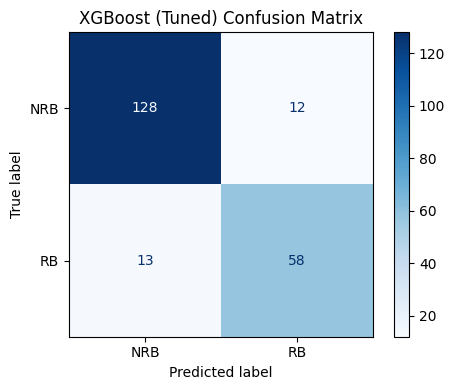

Summary of tuned model metrics:
             model  accuracy  precision    recall        f1
0  XGBoost (Tuned)  0.881517   0.828571  0.816901  0.822695


In [22]:
# Train best XGBoost on full training set, evaluate on test set

best_xgb = grid.best_estimator_
best_xgb.fit(X_train, y_train)

y_pred_xgb_best = best_xgb.predict(X_test)

fig, ax = plt.subplots(1,1, figsize=(5,4))
xgb_best_results = evaluate_model("XGBoost (Tuned)", y_test, y_pred_xgb_best, ax=ax)
plt.tight_layout()
plt.show()

print("Summary of tuned model metrics:")
print(pd.DataFrame([xgb_best_results]))


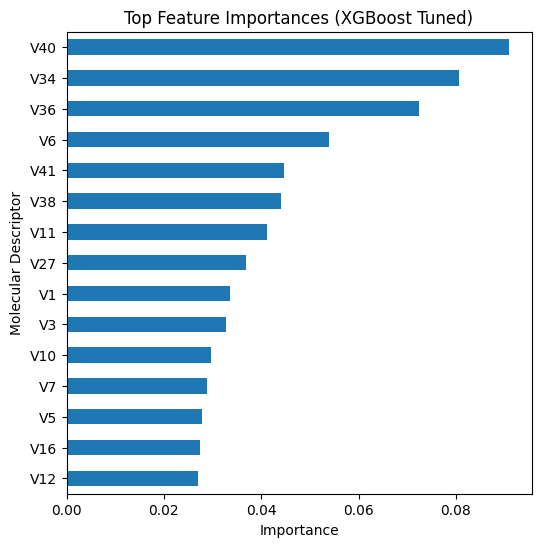

In [23]:
# Feature importance for tuned XGBoost
importances_best = best_xgb.feature_importances_
imp_series_best = pd.Series(importances_best, index=X.columns).sort_values(ascending=False)

top_k = 15
plt.figure(figsize=(6,6))
imp_series_best.head(top_k).iloc[::-1].plot(kind='barh')
plt.title("Top Feature Importances (XGBoost Tuned)")
plt.xlabel("Importance")
plt.ylabel("Molecular Descriptor")
plt.show()



### 💬 Summary and Discussion

This lab provided a hands-on understanding of classification, from mathematical intuition to evaluating real-world performance.

**Key Takeaways:**

- Logistic Regression can be implemented entirely with **NumPy**, deepening understanding of gradient descent and binary cross-entropy loss.  
- Proper **feature scaling**, **data splitting**, and **class balancing** are essential for stable and fair model performance.  
- Comparing models showed that:  
  - **Logistic Regression** offers interpretability and simplicity.  
  - **Random Forest** and **XGBoost** handle nonlinear patterns effectively.  
  - **SVM** performs well with scaled data but is sensitive to parameter settings.  
- The **Precision–Recall curve** clearly demonstrated the tradeoff between catching more RB compounds (recall) and avoiding false positives (precision).  
- **Hyperparameter tuning** improved XGBoost’s performance, highlighting the impact of systematic model optimization.

**Reflection:**  
By completing this lab, you learned how to:
- Build binary classifiers from scratch and with libraries.  
- Evaluate and interpret multiple performance metrics.  
- Understand when to prioritize recall over precision in scientific classification problems such as predicting chemical biodegradability.


### Sources:
*   https://www.kaggle.com/datasets/muhammetvarl/qsarbiodegradation
*   https://archive.ics.uci.edu/dataset/254/qsar+biodegradation

### Contributed By: Yazan Alshoibi

